<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


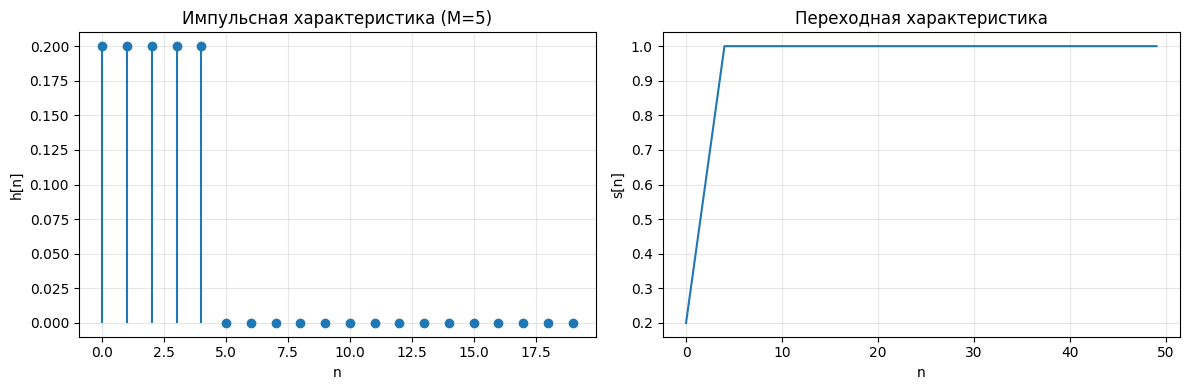

In [6]:
# Задание 1.1
M = 5
b = np.ones(M) / M
a = [1]

# Импульс
impulse = np.zeros(20)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)

# Скачок
step = np.ones(50)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.stem(np.arange(len(h)), h, basefmt=' ')
plt.title(f'Импульсная характеристика (M={M})')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.xlabel('n')
plt.ylabel('s[n]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


**Ответ:**  
Импульсная характеристика конечная, потому что скользящее среднее является КИХ-фильтром: в выходном значении участвуют только последние `M` отсчётов. После того как импульс полностью выходит за окно, отклик становится равным нулю. Переходная характеристика выходит на постоянный уровень, так как входной скачок постоянный, а сумма нормированных коэффициентов фильтра равна 1.

### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


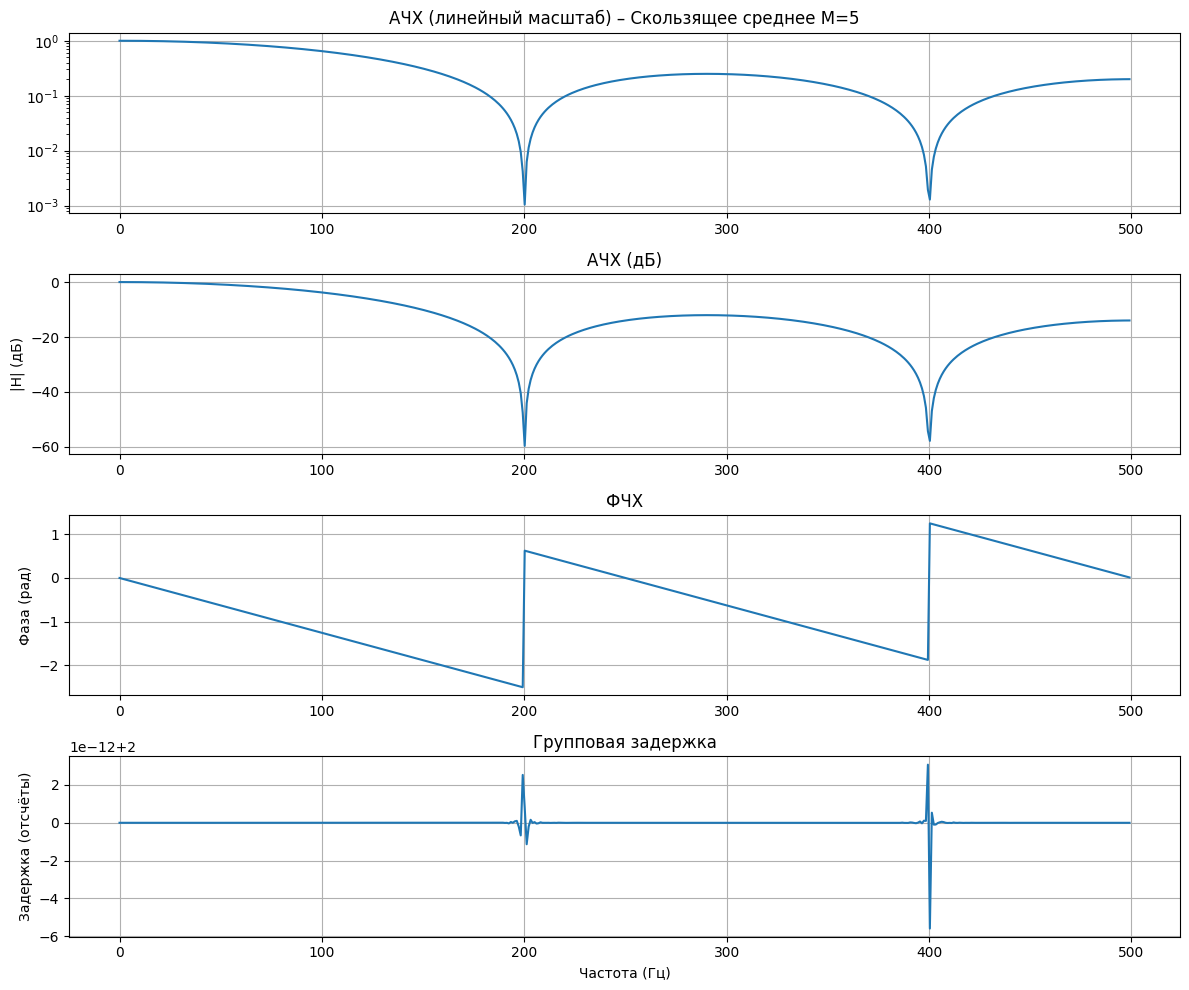

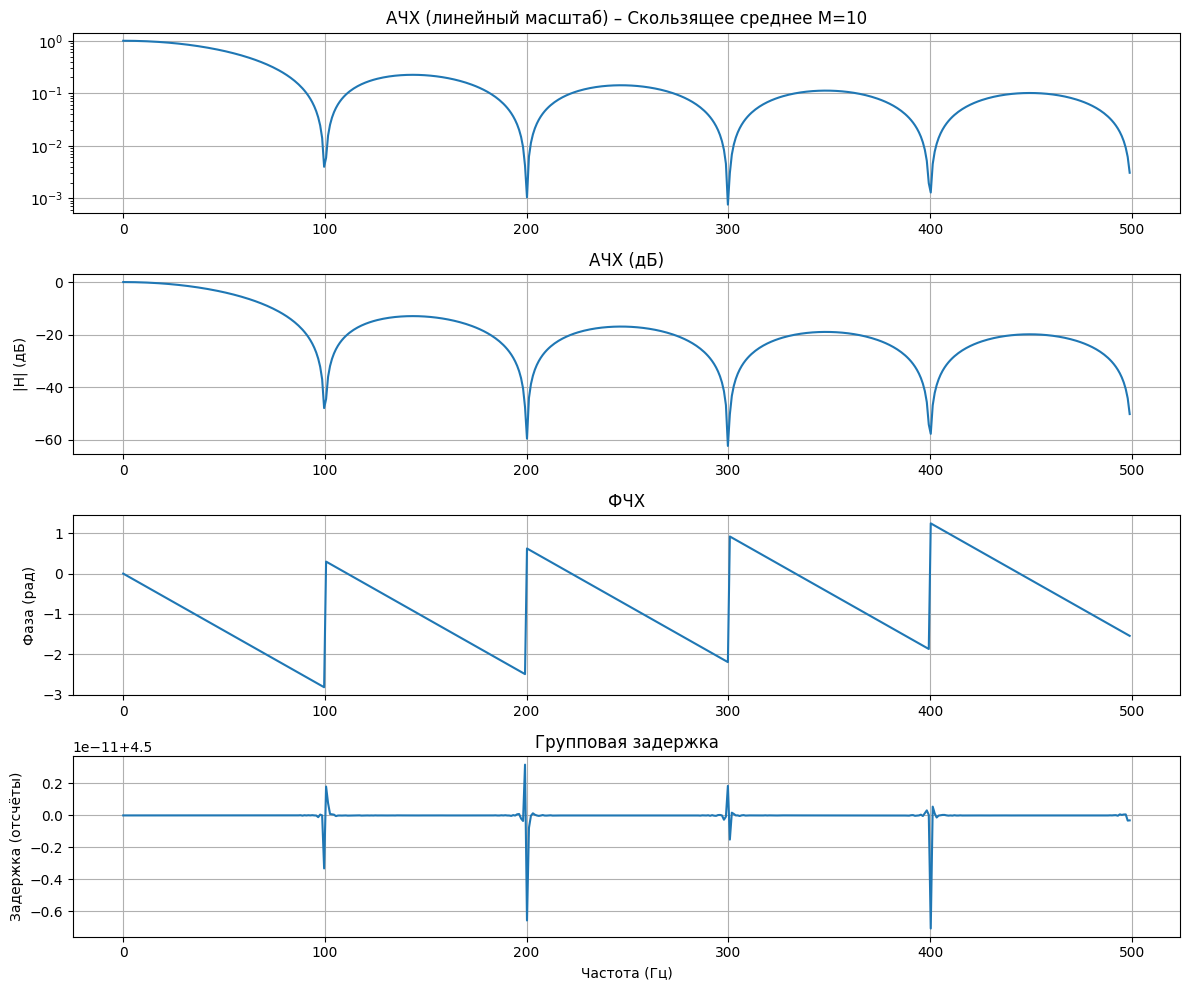

C:\Users\tooly\AppData\Local\Temp\ipykernel_2356\3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


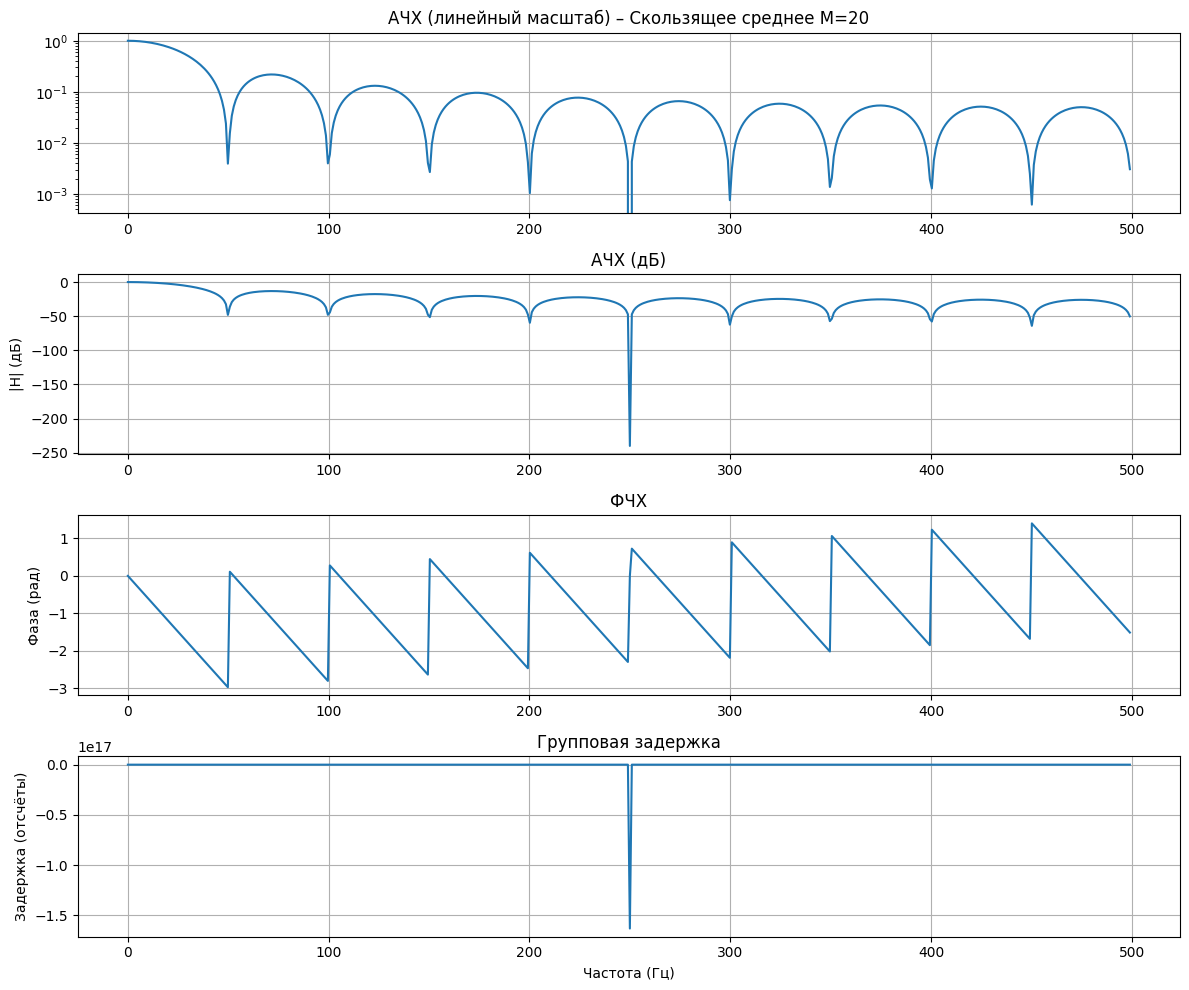

In [7]:
for M in [5, 10, 20]:
    b = np.ones(M) / M
    plot_filter_response(b, [1], fs=1000, title=f'Скользящее среднее M={M}')

**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


**Ответ:**  
При увеличении `M` фильтр сильнее подавляет высокие частоты, а переходная область АЧХ становится уже. Одновременно возрастает задержка, потому что фильтр использует больше соседних отсчётов. ФЧХ у скользящего среднего остаётся почти линейной, но её наклон увеличивается, что соответствует большей групповой задержке.

### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


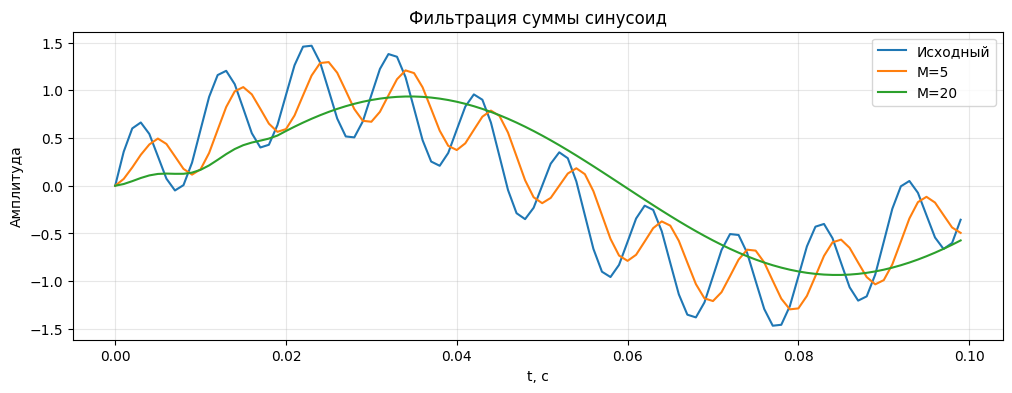

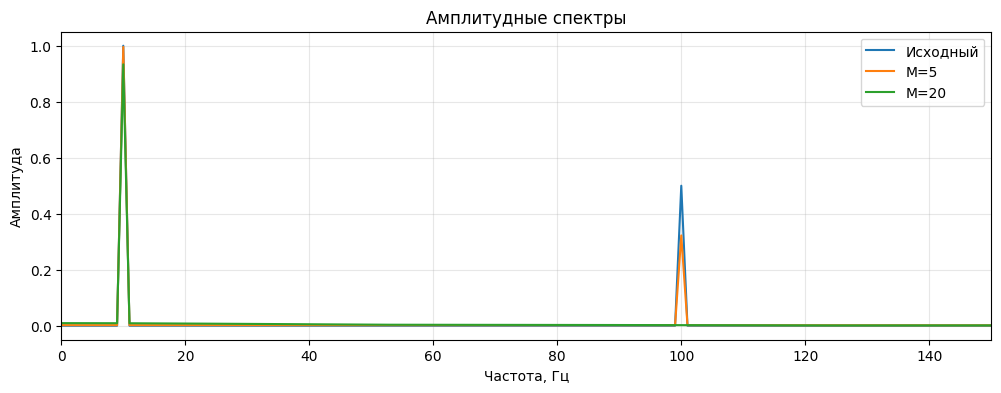

In [8]:
fs = 1000
t = np.arange(0, 1, 1 / fs)
x = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 100 * t)

def moving_average(sig, M):
    return signal.lfilter(np.ones(M) / M, [1], sig)

y5 = moving_average(x, 5)
y20 = moving_average(x, 20)

plt.figure(figsize=(12, 4))
plt.plot(t[:100], x[:100], label='Исходный')
plt.plot(t[:100], y5[:100], label='M=5')
plt.plot(t[:100], y20[:100], label='M=20')
plt.title('Фильтрация суммы синусоид')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Спектры
def plot_spectrum(s, label):
    X = np.fft.rfft(s)
    freq = np.fft.rfftfreq(len(s), 1 / fs)
    amp = 2 * np.abs(X) / len(s)
    plt.plot(freq, amp, label=label)

plt.figure(figsize=(12, 4))
plot_spectrum(x, 'Исходный')
plot_spectrum(y5, 'M=5')
plot_spectrum(y20, 'M=20')
plt.title('Амплитудные спектры')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 150)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


**Ответ:**  
Чем больше `M`, тем заметнее уменьшается амплитуда компоненты 100 Гц. Это происходит потому, что скользящее среднее является низкочастотным фильтром: медленные изменения проходят лучше, а быстрые колебания усредняются и подавляются. Результат фильтрации напрямую связан с АЧХ: на частотах, где значение АЧХ меньше, соответствующие спектральные компоненты на выходе становятся слабее.

## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


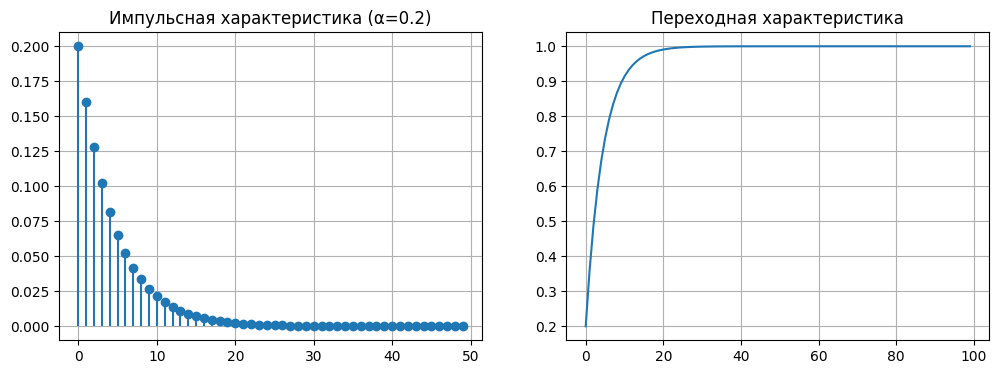

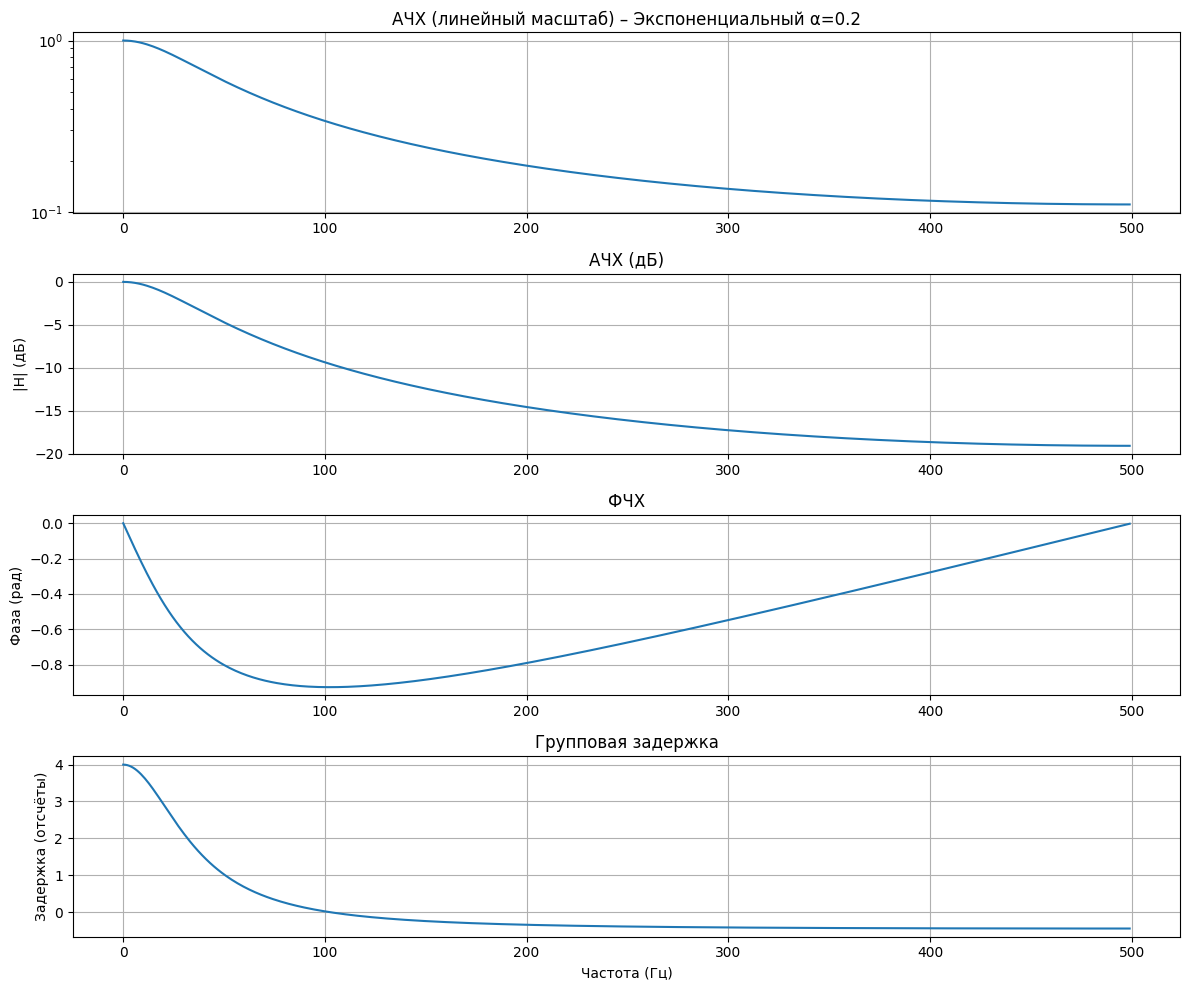

In [9]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

# Импульсная характеристика (длина 50)
impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)
# Переходная характеристика (длина 100)
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

# Частотные характеристики
plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


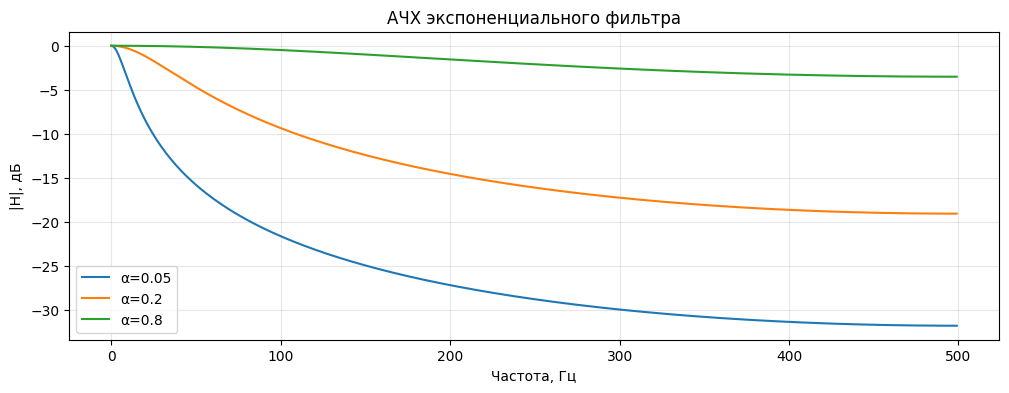

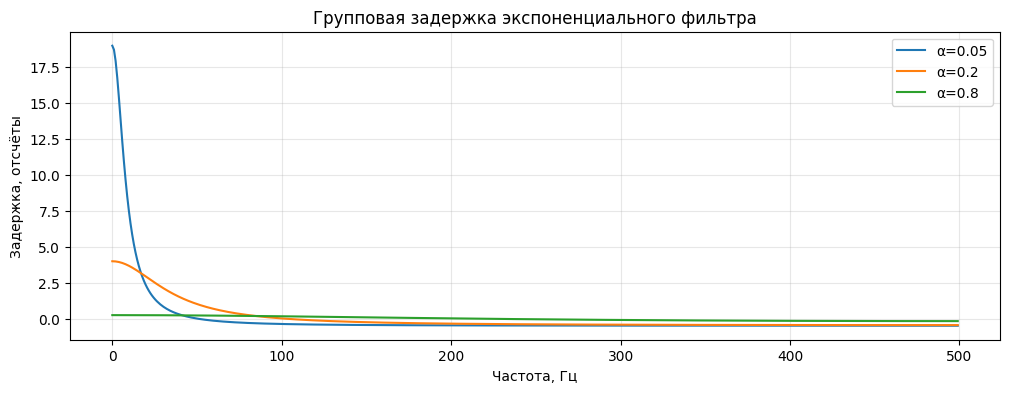

In [10]:
alphas = [0.05, 0.2, 0.8]

plt.figure(figsize=(12, 4))
for alpha in alphas:
    b = [alpha]
    a = [1, -(1 - alpha)]
    w, H = signal.freqz(b, a, fs=1000)
    plt.plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=f'α={alpha}')
plt.title('АЧХ экспоненциального фильтра')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for alpha in alphas:
    b = [alpha]
    a = [1, -(1 - alpha)]
    w_gd, gd = signal.group_delay((b, a), fs=1000)
    plt.plot(w_gd, gd, label=f'α={alpha}')
plt.title('Групповая задержка экспоненциального фильтра')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


**Ответ:**  
Малое значение `α` даёт более сильное сглаживание: фильтр медленнее реагирует на изменения, сильнее подавляет высокие частоты и вносит большую задержку. При большом `α` выход быстрее следует за входом, спад АЧХ становится менее крутым, шум подавляется слабее, зато задержка меньше.

### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


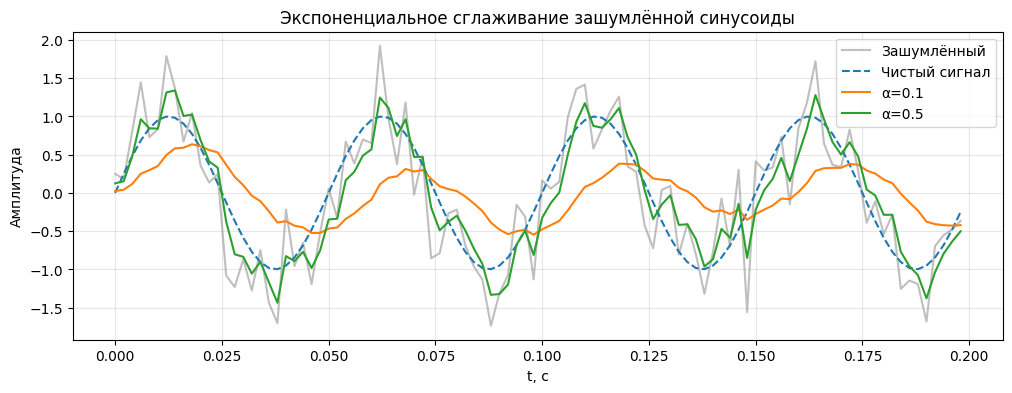

In [11]:
np.random.seed(42)
fs = 500
t = np.arange(0, 1, 1 / fs)
x_clean = np.sin(2 * np.pi * 20 * t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

def exp_filter(sig, alpha):
    b = [alpha]
    a = [1, -(1 - alpha)]
    return signal.lfilter(b, a, sig)

y01 = exp_filter(x_noisy, 0.1)
y05 = exp_filter(x_noisy, 0.5)

plt.figure(figsize=(12, 4))
plt.plot(t[:100], x_noisy[:100], color='gray', alpha=0.5, label='Зашумлённый')
plt.plot(t[:100], x_clean[:100], linestyle='--', label='Чистый сигнал')
plt.plot(t[:100], y01[:100], label='α=0.1')
plt.plot(t[:100], y05[:100], label='α=0.5')
plt.title('Экспоненциальное сглаживание зашумлённой синусоиды')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


**Ответ:**  
На временном графике групповая задержка проявляется как сдвиг отфильтрованного сигнала вправо относительно исходного. При меньшем `α` сглаживание сильнее, поэтому максимум и минимум сигнала появляются позже. При большем `α` задержка меньше, но шум подавляется хуже.

## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


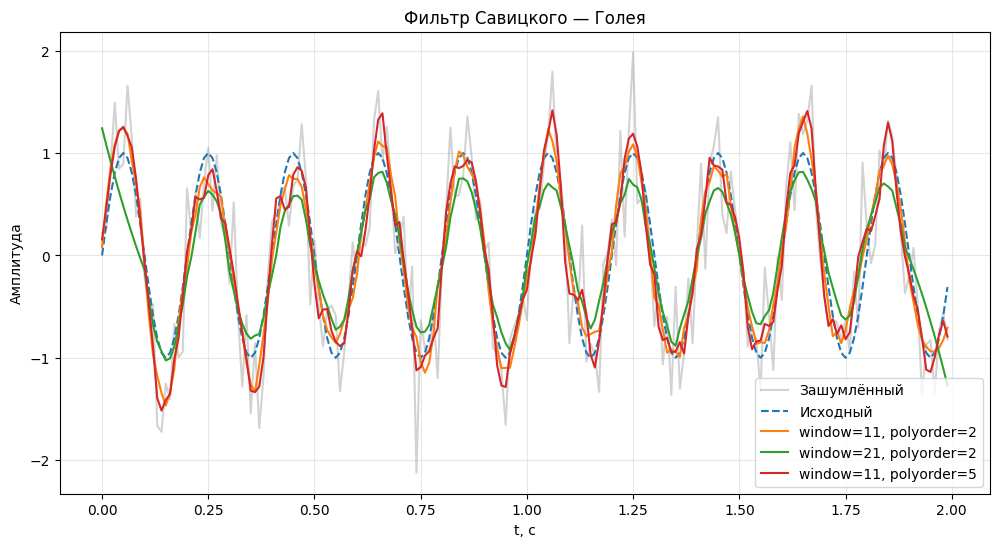

In [12]:
np.random.seed(42)
fs = 100
t = np.arange(0, 2, 1 / fs)
x_clean = np.sin(2 * np.pi * 5 * t)
noise = np.sqrt(0.2) * np.random.randn(len(t))
x_noisy = x_clean + noise

y_11_2 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y_21_2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y_11_5 = savgol_filter(x_noisy, window_length=11, polyorder=5)

plt.figure(figsize=(12, 6))
plt.plot(t, x_noisy, color='gray', alpha=0.35, label='Зашумлённый')
plt.plot(t, x_clean, linestyle='--', label='Исходный')
plt.plot(t, y_11_2, label='window=11, polyorder=2')
plt.plot(t, y_21_2, label='window=21, polyorder=2')
plt.plot(t, y_11_5, label='window=11, polyorder=5')
plt.title('Фильтр Савицкого — Голея')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


**Ответ:**  
Увеличение `window_length` усиливает сглаживание, потому что фильтр использует больше точек. Но слишком большое окно может сильнее искажать быстрые изменения сигнала. Увеличение `polyorder` позволяет лучше повторять форму локального участка, поэтому пики и изгибы сохраняются точнее, но при слишком большом порядке фильтр может начать хуже подавлять шум.

### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


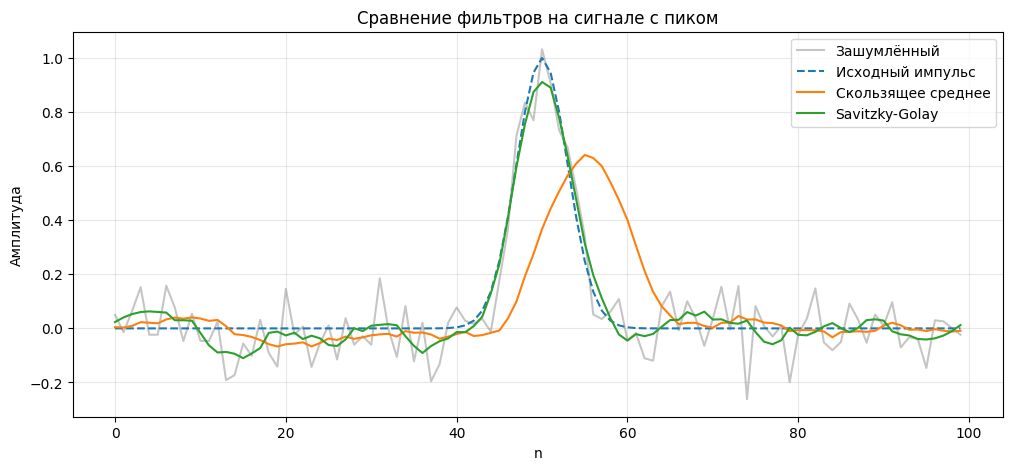

In [13]:
np.random.seed(42)
N = 100
n = np.arange(N)
sigma = 3
x_clean_pulse = np.exp(-(n - N // 2) ** 2 / (2 * sigma ** 2))
x_clean_pulse = x_clean_pulse / np.max(x_clean_pulse)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

win = 11
ma_coeffs = np.ones(win) / win
y_ma = signal.lfilter(ma_coeffs, [1], x_noisy_pulse)
y_sg = savgol_filter(x_noisy_pulse, window_length=win, polyorder=2)

plt.figure(figsize=(12, 5))
plt.plot(x_noisy_pulse, color='gray', alpha=0.45, label='Зашумлённый')
plt.plot(x_clean_pulse, linestyle='--', label='Исходный импульс')
plt.plot(y_ma, label='Скользящее среднее')
plt.plot(y_sg, label='Savitzky-Golay')
plt.title('Сравнение фильтров на сигнале с пиком')
plt.xlabel('n')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:**  
Фильтр Савицкого — Голея лучше сохраняет пик: его максимум меньше «размазывается», а форма ближе к исходному гауссову импульсу. Скользящее среднее сильнее усредняет соседние точки, поэтому пик получается ниже и шире.

### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


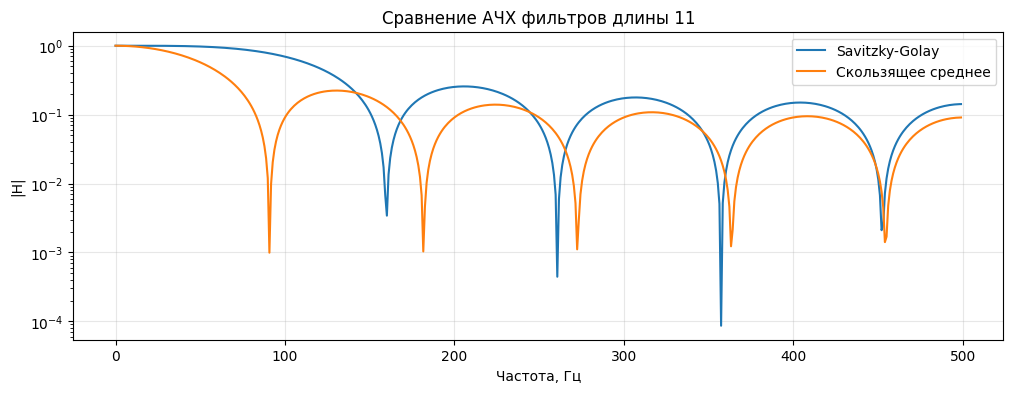

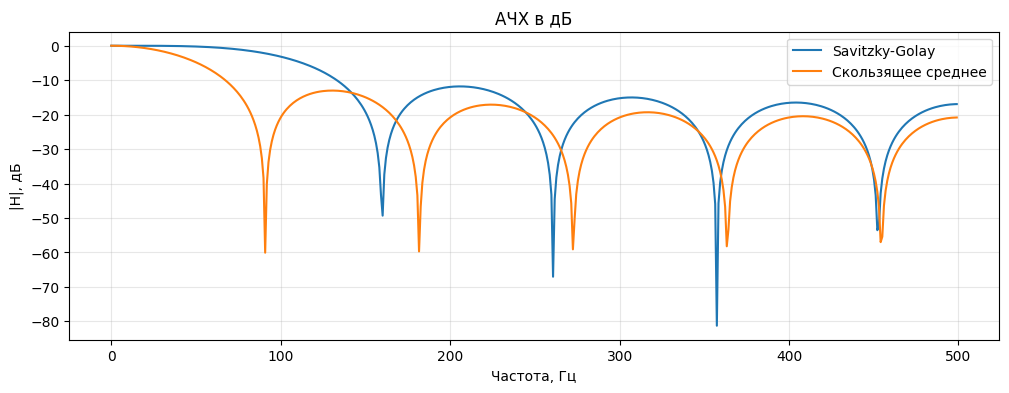

In [14]:
window_length = 11
polyorder = 2
coeffs_sg = savgol_coeffs(window_length, polyorder)
coeffs_sg = coeffs_sg / np.sum(coeffs_sg)
coeffs_ma = np.ones(window_length) / window_length

w_sg, H_sg = signal.freqz(coeffs_sg, [1], fs=1000)
w_ma, H_ma = signal.freqz(coeffs_ma, [1], fs=1000)

plt.figure(figsize=(12, 4))
plt.semilogy(w_sg, np.abs(H_sg), label='Savitzky-Golay')
plt.semilogy(w_ma, np.abs(H_ma), label='Скользящее среднее')
plt.title('Сравнение АЧХ фильтров длины 11')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(w_sg, 20 * np.log10(np.abs(H_sg) + 1e-12), label='Savitzky-Golay')
plt.plot(w_ma, 20 * np.log10(np.abs(H_ma) + 1e-12), label='Скользящее среднее')
plt.title('АЧХ в дБ')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


**Ответ:**  
АЧХ Savitzky–Golay обычно ровнее в области низких частот, поэтому полезные медленные компоненты и форма сигнала сохраняются лучше. Скользящее среднее сильнее усредняет сигнал и быстрее ослабляет часть полезных частот, из-за чего пики и резкие элементы формы становятся более сглаженными.

### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


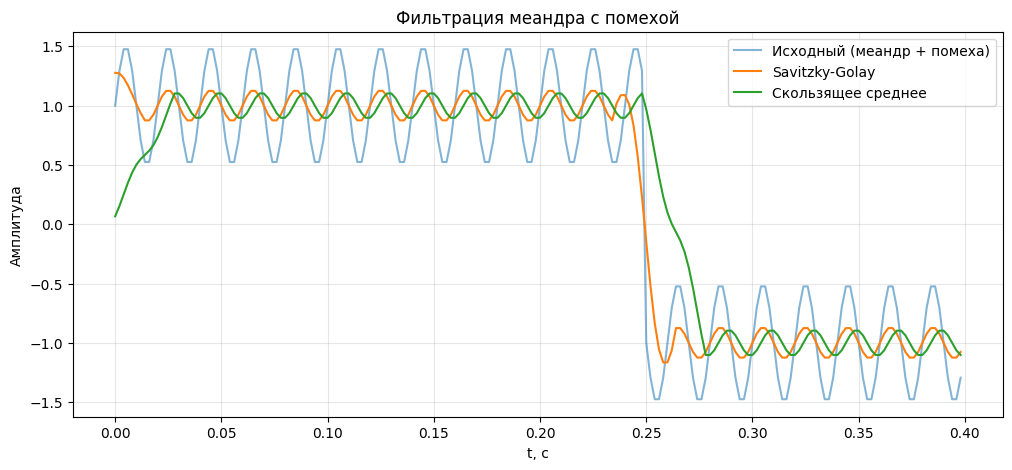

In [15]:
fs = 500
t = np.arange(0, 1, 1 / fs)
meander = signal.square(2 * np.pi * 2 * t)
interference = 0.5 * np.sin(2 * np.pi * 50 * t)
x_meander = meander + interference

win = 15
y_sg_meander = savgol_filter(x_meander, window_length=win, polyorder=3)
y_ma_meander = signal.lfilter(np.ones(win) / win, [1], x_meander)

plt.figure(figsize=(12, 5))
plt.plot(t[:200], x_meander[:200], label='Исходный (меандр + помеха)', alpha=0.55)
plt.plot(t[:200], y_sg_meander[:200], label='Savitzky-Golay')
plt.plot(t[:200], y_ma_meander[:200], label='Скользящее среднее')
plt.title('Фильтрация меандра с помехой')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


**Ответ:**  
Для сигналов с резкими фронтами лучше подходит Savitzky–Golay, потому что он сглаживает помеху, но меньше размывает переходы. Скользящее среднее заметнее округляет фронты и вносит более выраженное запаздывание.

## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


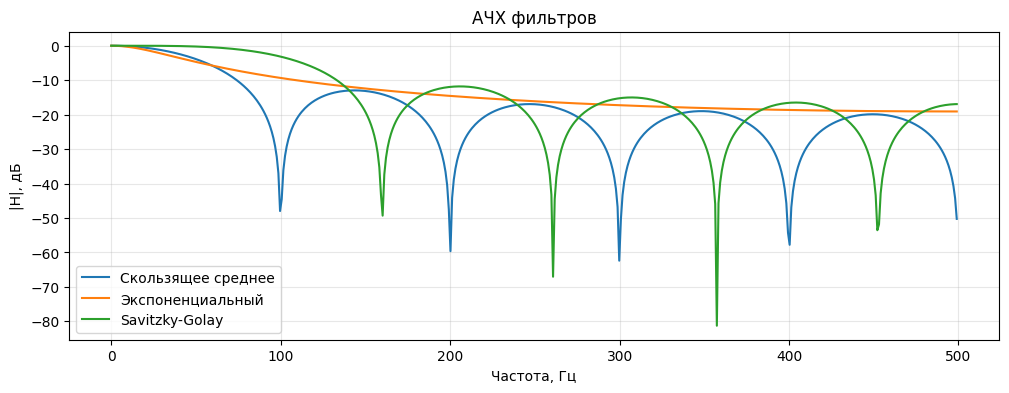

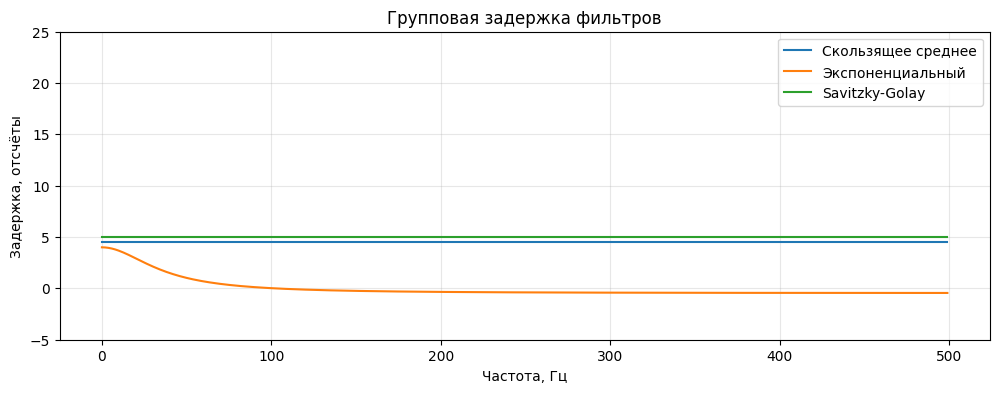

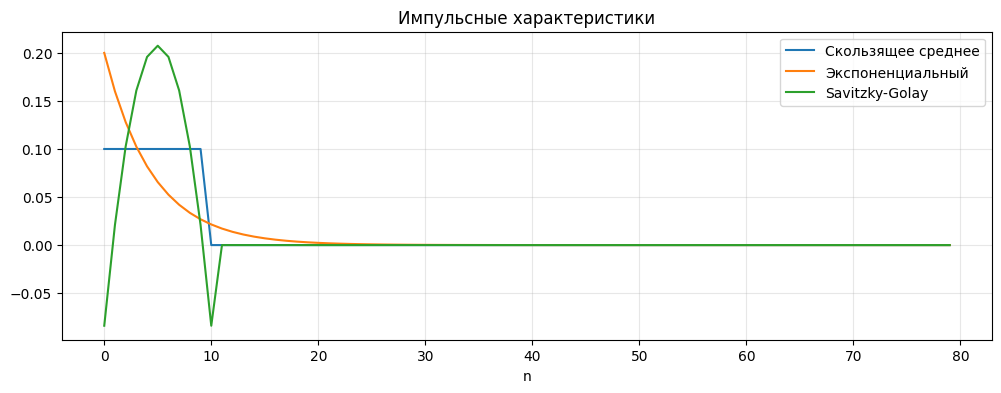

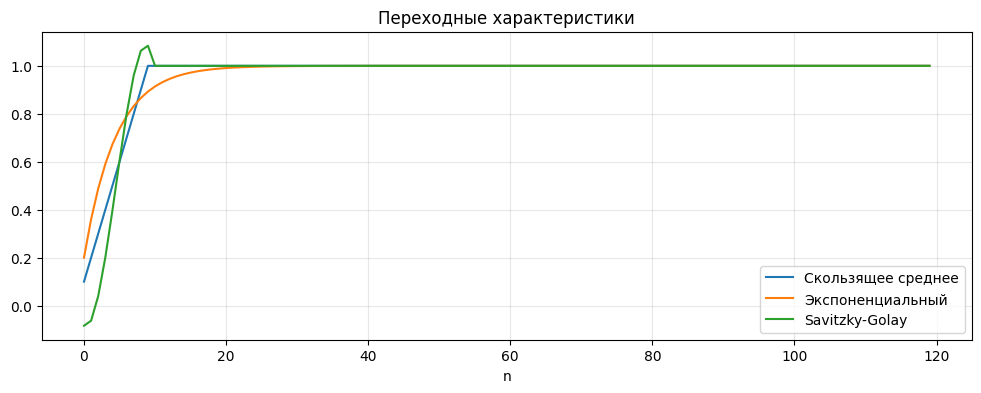

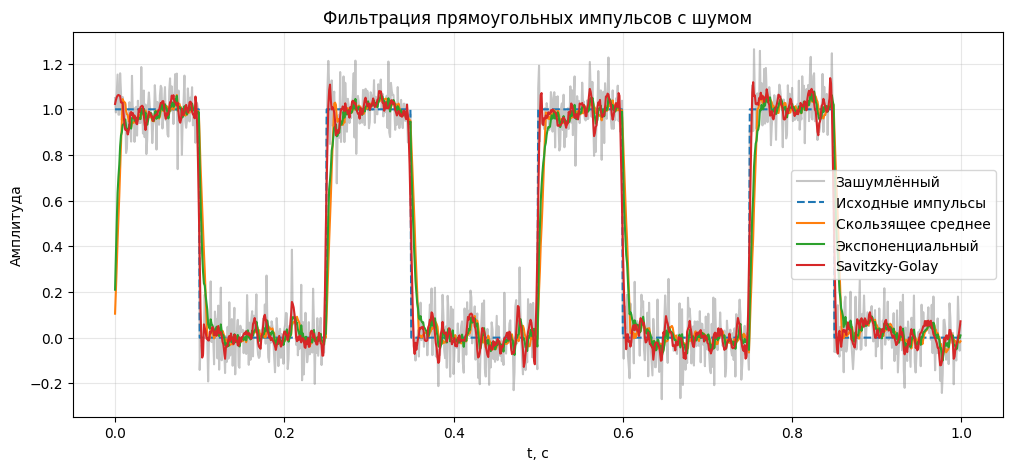

In [16]:
np.random.seed(42)

# Сигнал с прямоугольными импульсами
fs = 1000
t = np.arange(0, 1, 1 / fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

# Коэффициенты фильтров
M = 10
b_ma = np.ones(M) / M
a_ma = [1]

alpha = 0.2
b_exp = [alpha]
a_exp = [1, -(1 - alpha)]

b_sg = savgol_coeffs(11, 2)
b_sg = b_sg / np.sum(b_sg)
a_sg = [1]

filters = {
    'Скользящее среднее': (b_ma, a_ma),
    'Экспоненциальный': (b_exp, a_exp),
    'Savitzky-Golay': (b_sg, a_sg),
}

# 1. АЧХ и групповая задержка
plt.figure(figsize=(12, 4))
for name, (b, a) in filters.items():
    w, H = signal.freqz(b, a, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=name)
plt.title('АЧХ фильтров')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for name, (b, a) in filters.items():
    w_gd, gd = signal.group_delay((b, a), fs=fs)
    plt.plot(w_gd, gd, label=name)
plt.title('Групповая задержка фильтров')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.ylim(-5, 25)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 2. Реакции на импульс и скачок
impulse = np.zeros(80)
impulse[0] = 1
step = np.ones(120)

plt.figure(figsize=(12, 4))
for name, (b, a) in filters.items():
    plt.plot(signal.lfilter(b, a, impulse), label=name)
plt.title('Импульсные характеристики')
plt.xlabel('n')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for name, (b, a) in filters.items():
    plt.plot(signal.lfilter(b, a, step), label=name)
plt.title('Переходные характеристики')
plt.xlabel('n')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 3. Фильтрация импульсного сигнала с шумом
y_ma = signal.lfilter(b_ma, a_ma, x_pulse_noisy)
y_exp = signal.lfilter(b_exp, a_exp, x_pulse_noisy)
y_sg = savgol_filter(x_pulse_noisy, window_length=11, polyorder=2)

plt.figure(figsize=(12, 5))
plt.plot(t, x_pulse_noisy, color='gray', alpha=0.45, label='Зашумлённый')
plt.plot(t, pulse_train, linestyle='--', label='Исходные импульсы')
plt.plot(t, y_ma, label='Скользящее среднее')
plt.plot(t, y_exp, label='Экспоненциальный')
plt.plot(t, y_sg, label='Savitzky-Golay')
plt.title('Фильтрация прямоугольных импульсов с шумом')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


**Ответ:**  
Лучшее подавление шума обычно даёт скользящее среднее или экспоненциальный фильтр с малым параметром, но они сильнее сглаживают фронты и вносят задержку. Фильтр Savitzky–Golay лучше сохраняет резкие переходы и форму прямоугольных импульсов, хотя шум может подавляться немного слабее. Наименьшие фазовые искажения среди рассмотренных КИХ-фильтров дают симметричные фильтры со стабильной групповой задержкой: скользящее среднее и Savitzky–Golay. БИХ-фильтр имеет нелинейную фазу, поэтому фазовые искажения у него выражены сильнее.